# View of clapping movement measurements from audience members according to different systems 

In [1]:
import sys
import os
import time
import datetime as dt
import math
import numpy as np 
import scipy as sp
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
from IPython.display import Audio
import mir_eval.sonify

import emd

from scipy.signal import butter, filtfilt, argrelextrema
from scipy import interpolate
from scipy.interpolate import interp1d
from scipy.signal import find_peaks

In [2]:
out_loc = './Data/Processed/'
files = os.listdir(out_loc)
files

sources = ['rgb', 'ir', 'thermalhandheld', 'thermalbox', 'therdata','ax3','jerk']
labels = ['RGB', 'IR', 'Thermal(P)', 'Thermal(B)', 'Thermal(D)','|ACC|','|Jerk|']
source_labels = dict(zip(sources,labels))

smal_files = ['rgb_unk.csv','ir_unk.csv','thermalhandheld_unk.csv','thermalbox_unk.csv','therdata_smal.csv','acc_smal.csv','jerk_smal.csv']
smal_labels = dict(zip(smal_files,labels))

samplerates=dict(zip(labels,[59.97,59.97,25,50,4,400,10]))


In [3]:
partIDs =['AU1', 'AU2', 'AU3', 'AU4', 'AU5', 'AU7']
partID_palette={'AU1':'b', 'AU2':'r', 'AU3':'g', 'AU4':'m', 'AU5':'y', 'AU7':'k'}
claps1BPM = np.array([154,160,317,143,182,115]) #estimated from watching the videos
claps2BPM = np.array([163,176,220,161,140,115]) #estimated from watching the videos
claps1_Hz = dict(zip(partIDs,claps1BPM/60))
claps2_Hz = dict(zip(partIDs,claps2BPM/60))

In [4]:
QoMs = {}
for s in smal_files:
    Q = pd.read_csv(out_loc + s,index_col = 0)
    QoMs[smal_labels[s]] = Q.copy()

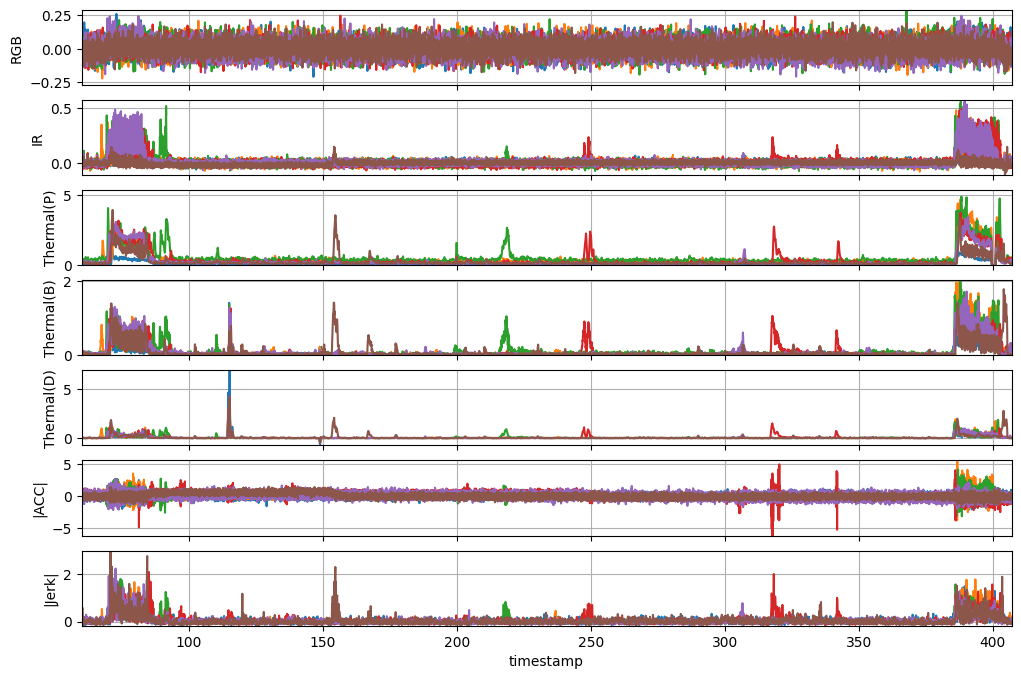

In [5]:
fig,axes = plt.subplots(len(sources),1,figsize=(12,len(sources)+1),sharex=True)
for i in range(len(sources)):
    s = sources[i]
    data = QoMs[source_labels[s]]
    data.plot(ax = axes[i],legend=False)
    ymax = data.max().max()
    ymin = data.min().min()

    axes[i].grid()
    axes[i].set(xlim = [60,407],ylabel = source_labels[s],ylim = [ymin,ymax])
plt.show()

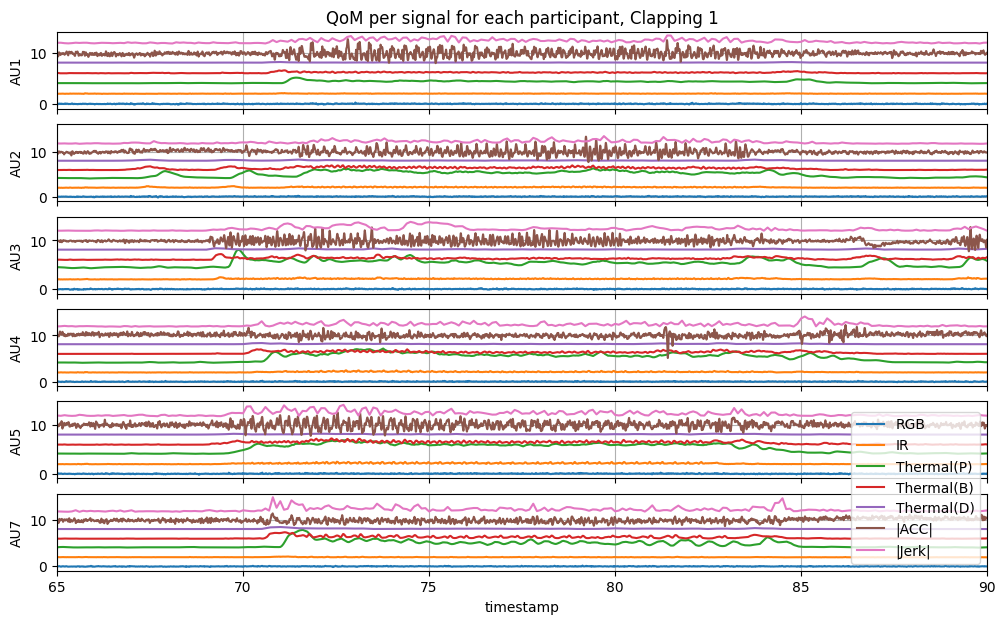

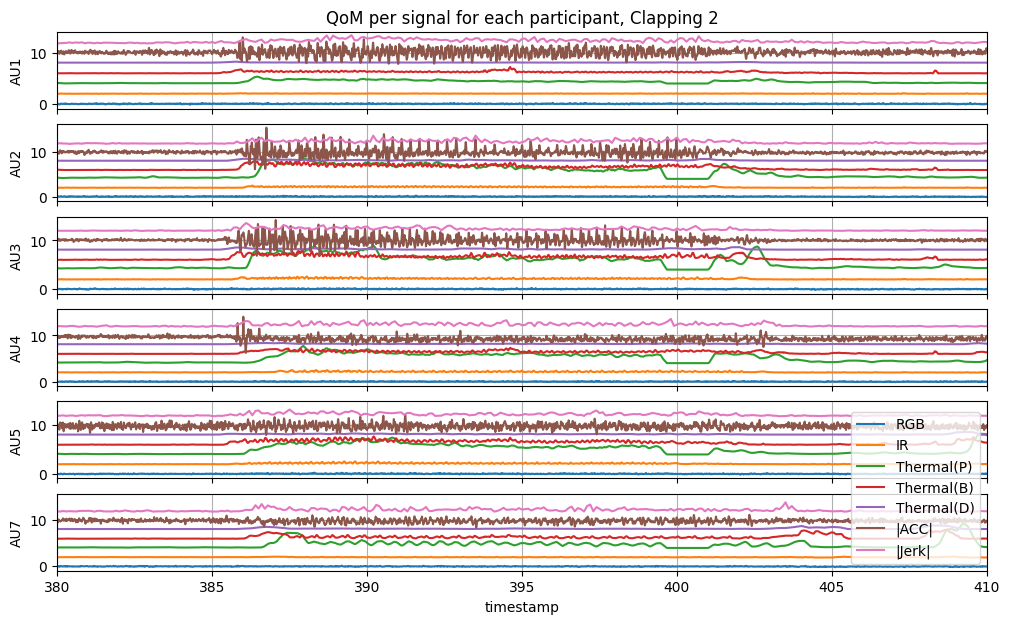

In [19]:
partIDs = ['AU1', 'AU2', 'AU3', 'AU4', 'AU5', 'AU7']
fig,axes = plt.subplots(len(partIDs),1,figsize=(12,len(partIDs)+1),sharex=True)
for i in range(len(partIDs)):
    part = partIDs[i]
    for j in range(len(sources)):
        s = sources[j]
        (QoMs[source_labels[s]].loc[:,part]+j*2).plot(ax = axes[i],label = source_labels[s])
    axes[i].grid()
    axes[i].set(xlim = [65,90],ylabel = part)
axes[0].set(title='QoM per signal for each participant, Clapping 1')
axes[i].legend(loc='lower right')
plt.savefig('./plots/'+ 'Claps1_strated.png',dpi = 300)
plt.show()

partIDs = ['AU1', 'AU2', 'AU3', 'AU4', 'AU5', 'AU7']
fig,axes = plt.subplots(len(partIDs),1,figsize=(12,len(partIDs)+1),sharex=True)
for i in range(len(partIDs)):
    part = partIDs[i]
    for j in range(len(sources)):
        s = sources[j]
        (QoMs[source_labels[s]].loc[:,part]+j*2).plot(ax = axes[i],label = source_labels[s])
    axes[i].grid()
    axes[i].set(xlim = [380,410],ylabel = part)
axes[0].set(title='QoM per signal for each participant, Clapping 2')
axes[i].legend(loc='lower right')
plt.savefig('./plots/'+ 'Claps2_strated_unk.png',dpi = 300)
plt.show()

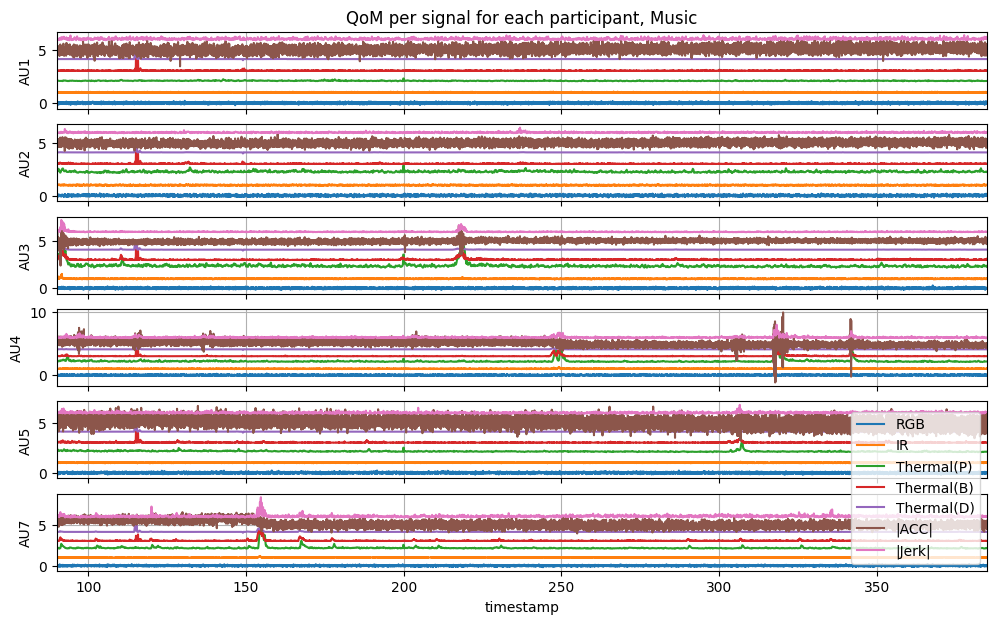

In [20]:
partIDs = ['AU1', 'AU2', 'AU3', 'AU4', 'AU5', 'AU7']
fig,axes = plt.subplots(len(partIDs),1,figsize=(12,len(partIDs)+1),sharex=True)
for i in range(len(partIDs)):
    part = partIDs[i]
    for j in range(len(sources)):
        s = sources[j]
        (QoMs[source_labels[s]].loc[90:385,part]+j).plot(ax = axes[i],label = source_labels[s])
    axes[i].grid()
    axes[i].set(xlim = [90,385],ylabel = part)
axes[0].set(title='QoM per signal for each participant, Music')
axes[i].legend(loc='lower right')
plt.savefig('./plots/'+ 'Music_strated_unk.png',dpi = 300)

plt.show()

# using only unkeyed cleaned measurements

In [6]:
CIMFs = {}
A = pd.read_csv('./Data/Initial/acc_dim/motion_normalized_roi_sizes.csv',index_col=0)
# A = pd.read_csv('/Users/finn/Desktop/Current_Projects/MotionComparisonPilot/QoM/'+ 'acc_dimtest_Claps.csv',index_col=0)
A.set_index('timestamp',inplace=True)



ClapIMFs = pd.DataFrame()
for col in ['AU1_Z', 'AU2_Z', 'AU3_Y','AU4_X', 'AU5_Z', 'AU7_Z']:
    ClapIMFs.loc[:,col.split('_')[0]]=A.loc[:412.0,col]
ext= ClapIMFs.columns
for col in ext: 
    ClapIMFs.loc[:,col]=(ClapIMFs.loc[:,col]-ClapIMFs.loc[:,col].mean())/(ClapIMFs.loc[:,col].quantile(0.995)-ClapIMFs.loc[:,col].quantile(0.5))

CIMFs['ACC_1D'] = ClapIMFs.copy()
print(ClapIMFs.columns)

ClapIMFs= pd.read_csv('/Users/finn/Desktop/Current_Projects/MotionComparisonPilot/QoM/smaled/ir_unk.csv',index_col=0).loc[:412.0,:]
ext= ClapIMFs.columns
fs = 60
for col in ext: 
    ClapIMFs.loc[:,col]=(ClapIMFs.loc[:,col]-ClapIMFs.loc[:,col].mean())/(ClapIMFs.loc[:,col].quantile(0.995)-ClapIMFs.loc[:,col].quantile(0.5))
CIMFs['IR'] = ClapIMFs.copy()
print(ClapIMFs.columns)

ClapIMFs= pd.read_csv('/Users/finn/Desktop/Current_Projects/MotionComparisonPilot/QoM/smaled/thermalbox_unk.csv',index_col=0).loc[:412.0,:]
ext= ClapIMFs.columns
fs = 50
for col in ext: 
    ClapIMFs.loc[:,col]=(ClapIMFs.loc[:,col]-ClapIMFs.loc[:,col].mean())/(ClapIMFs.loc[:,col].quantile(0.995)-ClapIMFs.loc[:,col].quantile(0.5))
CIMFs['Thermal(B)'] = ClapIMFs.copy()
print(ClapIMFs.columns)

ClapIMFs= pd.read_csv('/Users/finn/Desktop/Current_Projects/MotionComparisonPilot/QoM/smaled/thermalhandheld_unk.csv',index_col=0).loc[:412.0,:]
ext= ClapIMFs.columns
fs = 25
for col in ext: 
    ClapIMFs.loc[:,col]=(ClapIMFs.loc[:,col]-ClapIMFs.loc[:,col].mean())/(ClapIMFs.loc[:,col].quantile(0.995)-ClapIMFs.loc[:,col].quantile(0.5))
CIMFs['Thermal(P)'] = ClapIMFs.copy()
print(ClapIMFs.columns)


Index(['AU1', 'AU2', 'AU3', 'AU4', 'AU5', 'AU7'], dtype='object')
Index(['AU1', 'AU2', 'AU3', 'AU4', 'AU5', 'AU7'], dtype='object')
Index(['AU1', 'AU2', 'AU3', 'AU4', 'AU5', 'AU7'], dtype='object')
Index(['AU1', 'AU2', 'AU3', 'AU4', 'AU5', 'AU7'], dtype='object')


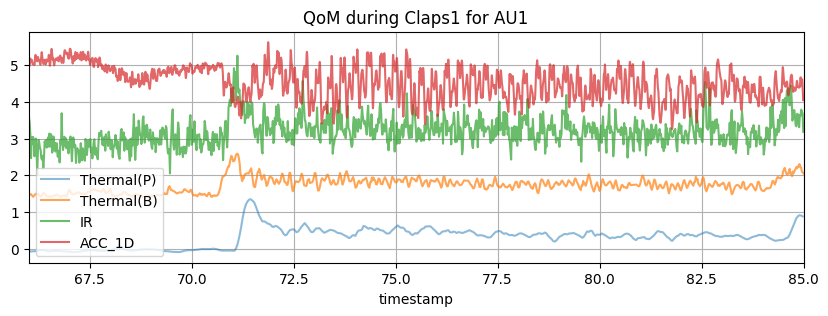

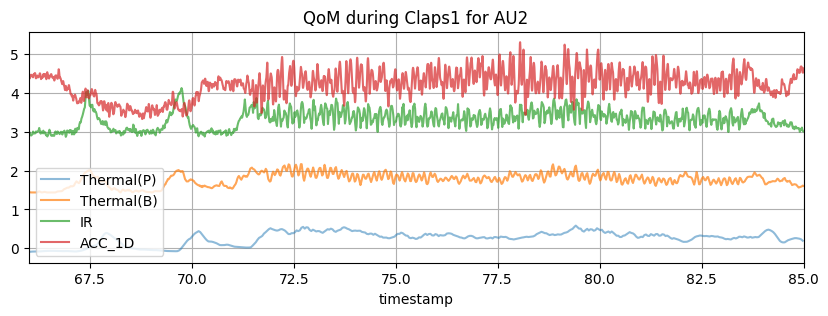

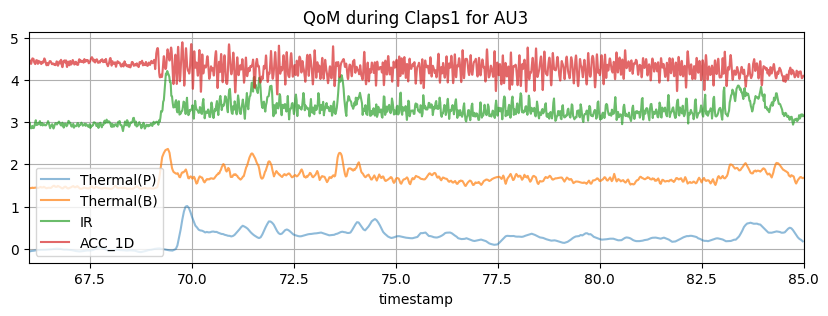

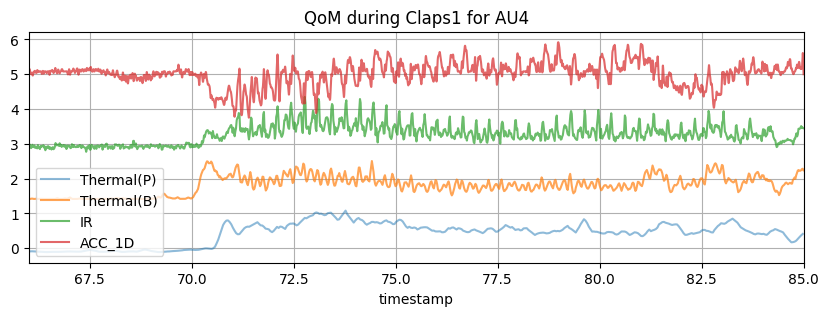

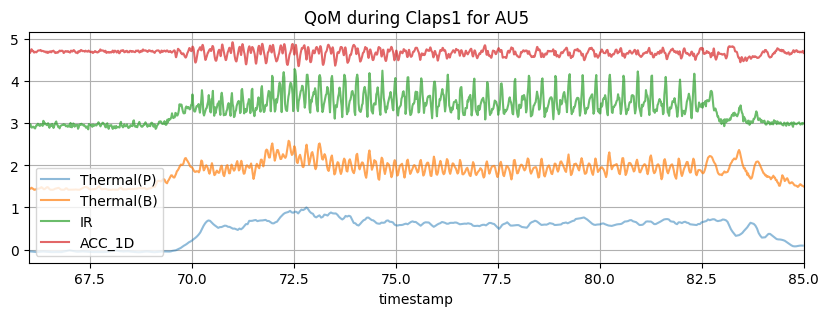

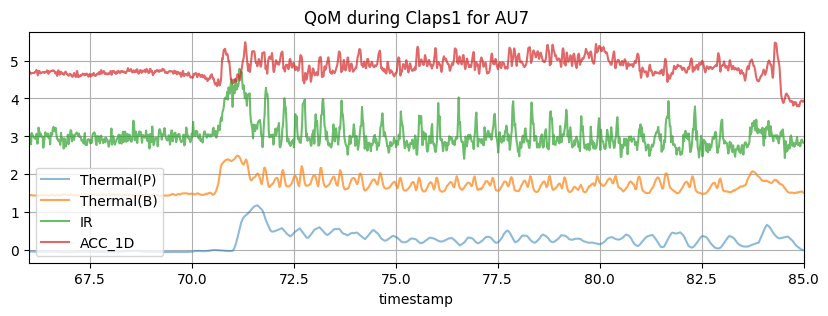

In [23]:
event = 'Claps1'
other_sigs = ['Thermal(B)','IR', 'ACC_1D',]
for i in range(len(ext)):
    s = 'Thermal(P)'
    df_ev = CIMFs[s].loc[65:85,:]
    df_ev[ext[i]].plot(figsize=(10,3),alpha=0.5,label=s)
    for j in range(len(other_sigs )):
        s = other_sigs[j]
        df_ev = CIMFs[s].loc[65:85,:]
        sig = df_ev[ext[i]].copy() + (j+1)*1.5
        # sig.loc[sig<sig.quantile(0.7)] = np.nan
        sig.plot(alpha=0.7,label=s)
        plt.grid()
    plt.legend(loc='lower left')
        # peak_index_list = find_peaks(sig,distance=mindist)[0]
        # plt.scatter(sig.iloc[peak_index_list].index,sig.iloc[peak_index_list].values)
    plt.title('QoM during ' + event + ' for ' + ext[i])
    plt.xlim([66,85])
    plt.savefig('./plots/'+ 'Comparative_QoM_clapping_'+ext[i]+'_' + event +'.png',dpi = 300)

    plt.show()

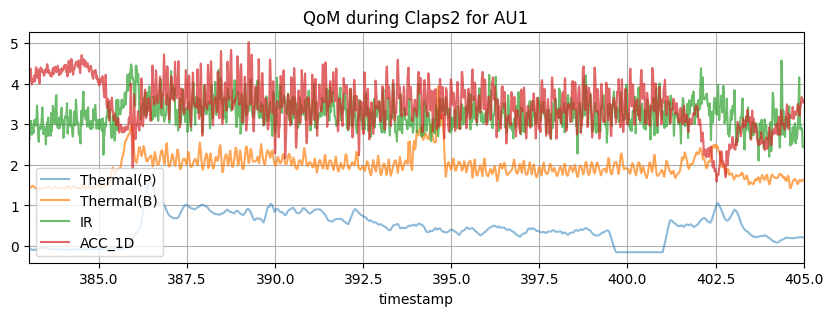

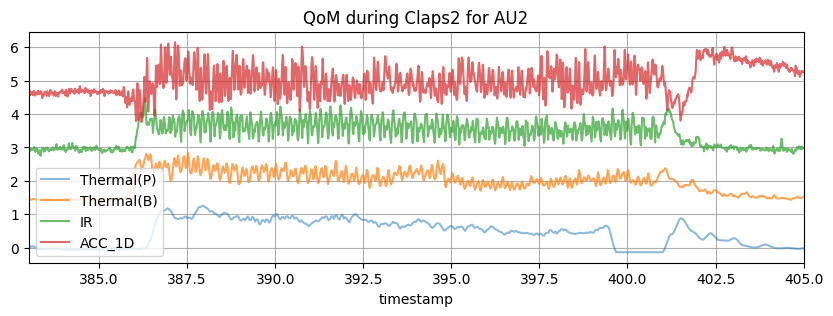

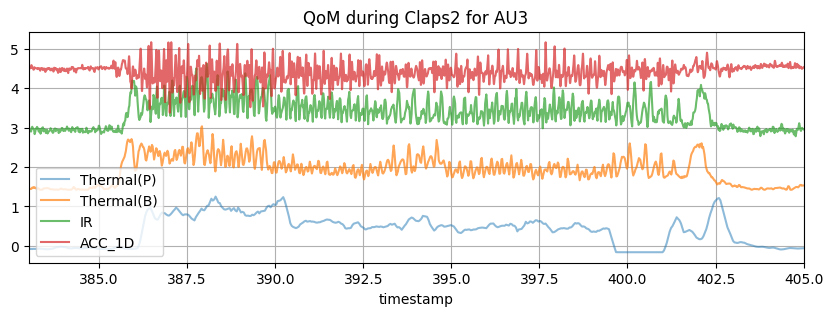

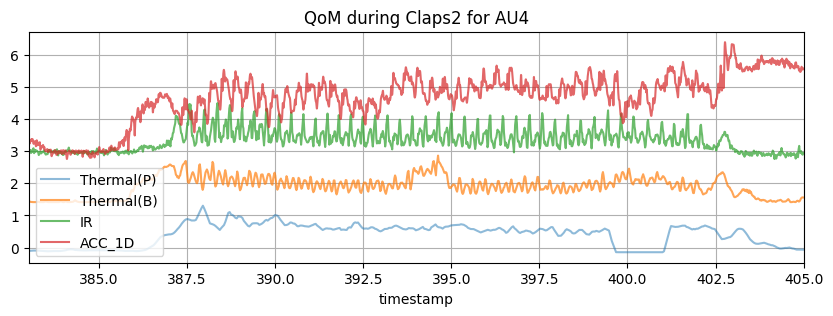

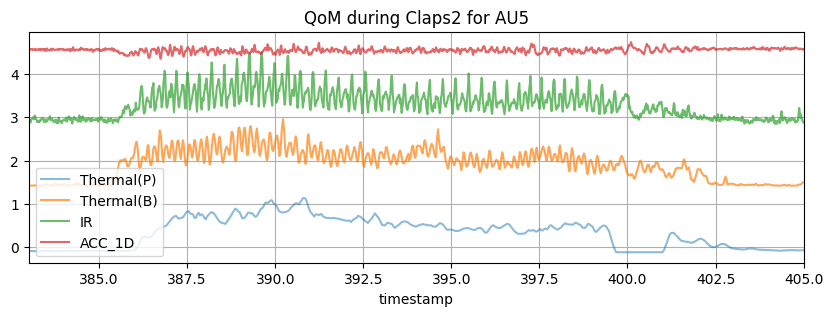

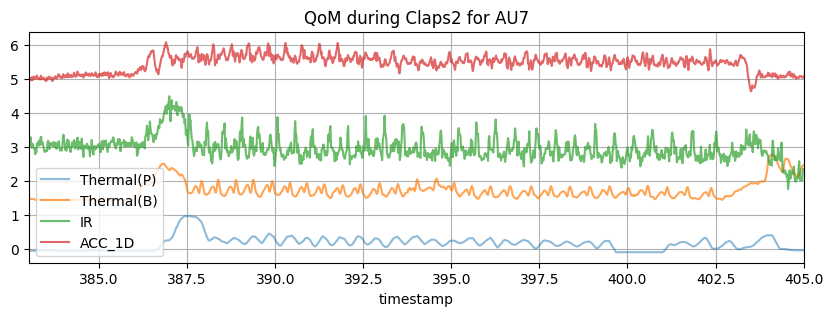

In [27]:
event = 'Claps2'
other_sigs = ['Thermal(B)','IR', 'ACC_1D',]
for i in range(len(ext)):
    s = 'Thermal(P)'
    df_ev = CIMFs[s].loc[383:405,:]
    df_ev[ext[i]].plot(figsize=(10,3),alpha=0.5,label=s)
    for j in range(len(other_sigs )):
        s = other_sigs[j]
        df_ev = CIMFs[s].loc[383:405,:]
        sig = df_ev[ext[i]].copy() + (j+1)*1.5
        # sig.loc[sig<sig.quantile(0.7)] = np.nan
        sig.plot(alpha=0.7,label=s)
        plt.grid()
    plt.legend(loc='lower left')
        # peak_index_list = find_peaks(sig,distance=mindist)[0]
        # plt.scatter(sig.iloc[peak_index_list].index,sig.iloc[peak_index_list].values)
    plt.title('QoM during ' + event + ' for ' + ext[i])
    plt.xlim([383,405])
    plt.savefig('./plots/'+ 'Comparative_QoM_clapping_'+ext[i]+'_' + event +'.png',dpi = 300)

    plt.show()

Thermal(P)
Thermal(B)
IR
ACC_1D


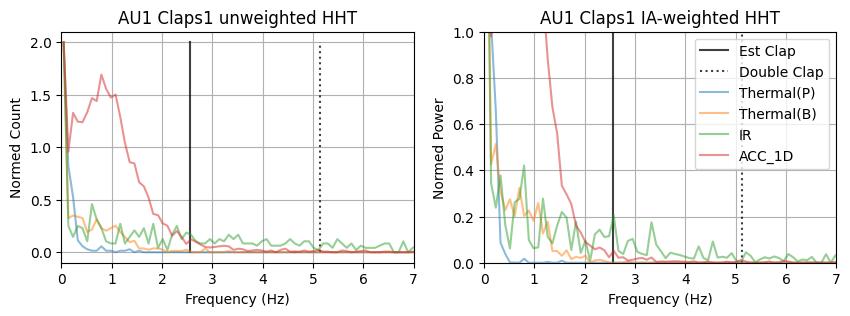

Thermal(P)
Thermal(B)
IR
ACC_1D


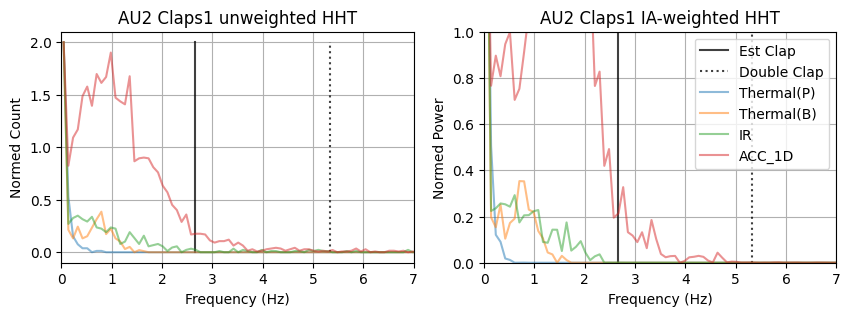

Thermal(P)
Thermal(B)
IR
ACC_1D


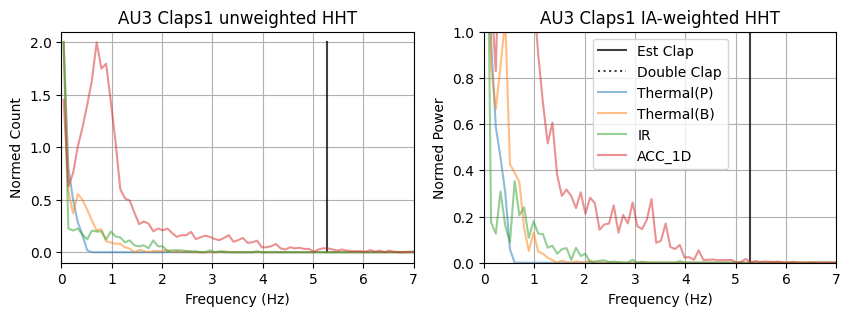

Thermal(P)
Thermal(B)
IR
ACC_1D


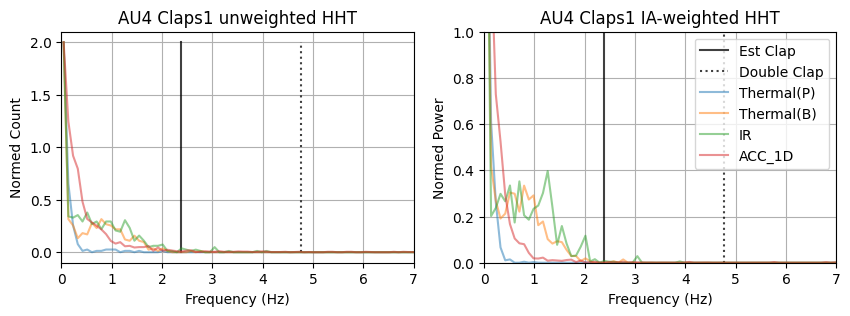

Thermal(P)
Thermal(B)
IR
ACC_1D


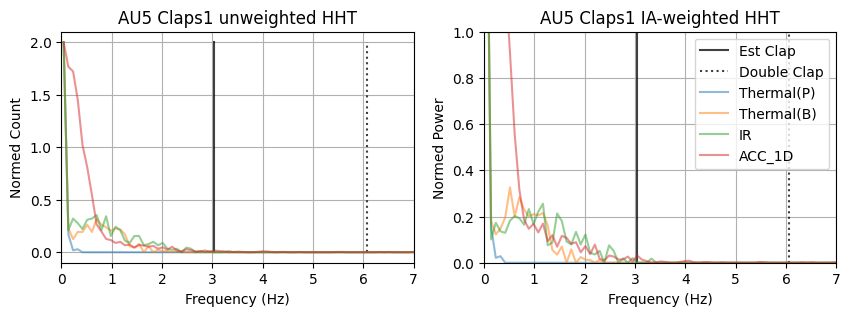

Thermal(P)
Thermal(B)
IR
ACC_1D


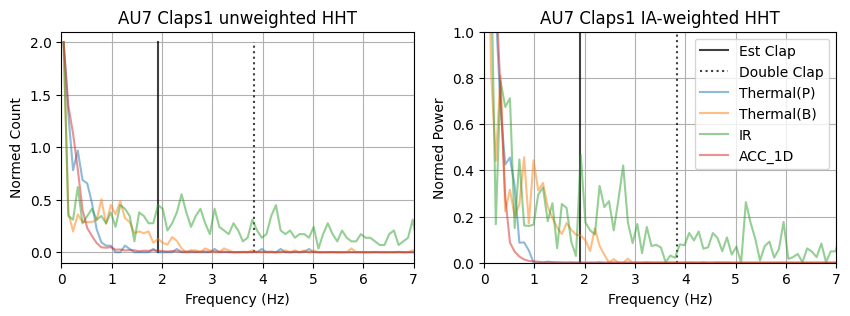

In [28]:
samplerates['ACC_1D'] = 60

for part in ['AU1','AU2','AU3','AU4','AU5','AU7']:
    event = 'Claps1'
    plt.figure(figsize=(10, 3))
    plt.subplots_adjust(hspace=0.4)
    plt.subplot(121)
    plt.xticks(np.arange(12)*1)
    plt.xlim(0, 7)
    plt.plot(claps1_Hz[part]*np.array([1,1]),[0,2],c ='k',alpha = 0.75,label='Est Clap')
    plt.plot(2*claps1_Hz[part]*np.array([1,1]),[0,2],c ='k',alpha = 0.75,linestyle=':',label='Double Clap')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Normed Count')
    plt.title(part+' ' + event +' unweighted HHT')
    plt.grid()
    
    plt.subplot(122) 
    plt.xticks(np.arange(12)*1)
    plt.xlim(0, 7)
    plt.ylim(0, 1)
    plt.plot(claps1_Hz[part]*np.array([1,1]),[0,2],c ='k',alpha = 0.75,label='Est Clap')
    plt.plot(2*claps1_Hz[part]*np.array([1,1]),[0,2],c ='k',alpha = 0.75,linestyle=':',label='Double Clap')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Normed Power')
    plt.title(part+' ' + event +' IA-weighted HHT')
    
    for s in ['Thermal(P)','Thermal(B)','IR', 'ACC_1D',]:
        print(s)
        ClapIMFs = CIMFs[s]
        fs = samplerates[s]
        sig = ClapIMFs.loc[70:83,part]
        timestamps = np.array(sig.index)
        W = sig.to_numpy()
        IP, IF, IA = emd.spectra.frequency_transform(W, fs, 'nht')
        
        freq_edges, freq_centres = emd.spectra.define_hist_bins(0, 12, 128, 'linear')
        f, spec_weighted = emd.spectra.hilberthuang(IF, IA, freq_edges, sum_imfs=False)
        f, spec_unweighted = emd.spectra.hilberthuang(IF, np.ones_like(IA), freq_edges, sum_imfs=False)

        plt.subplot(121)
        mrange = spec_unweighted.transpose().max()/2
        plt.plot(freq_centres, spec_unweighted/mrange,alpha = 0.5,label=s)
        
        plt.subplot(122)
        mrange = spec_weighted.transpose().max()/2
        plt.plot(freq_centres, spec_weighted/mrange,alpha = 0.5,label=s)
    plt.legend()
    plt.grid()
    plt.savefig('./plots/'+ 'HHTwuw'+'_' + event +'_'+part+'.png',dpi = 300)
    plt.show()


Thermal(P)
Thermal(B)
IR
ACC_1D


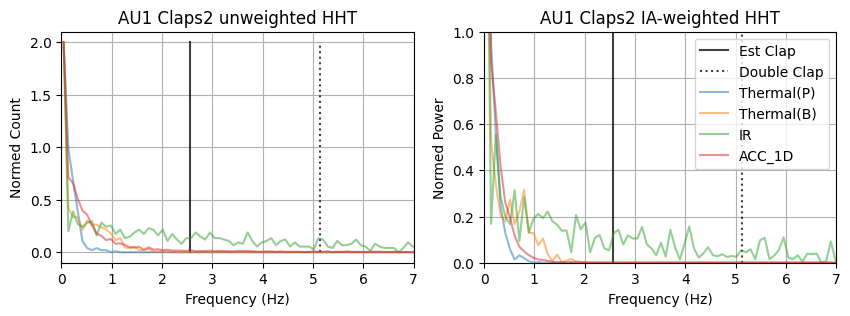

Thermal(P)
Thermal(B)
IR
ACC_1D


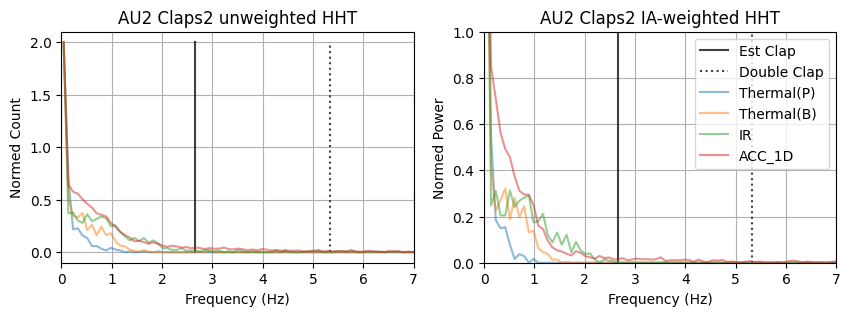

Thermal(P)
Thermal(B)
IR
ACC_1D


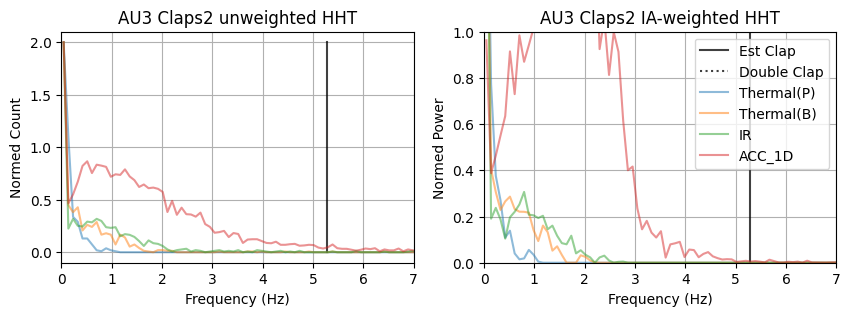

Thermal(P)
Thermal(B)
IR
ACC_1D


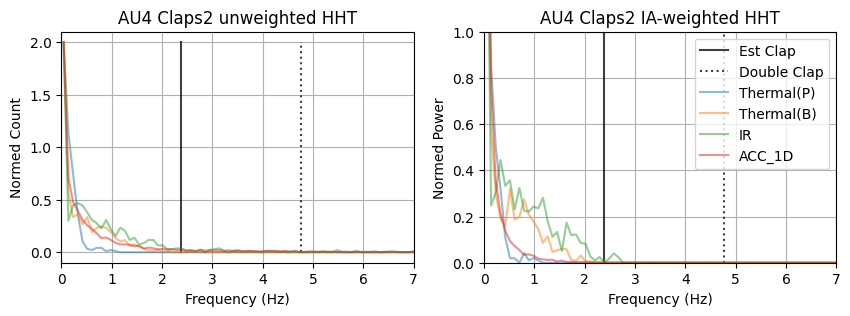

Thermal(P)
Thermal(B)
IR
ACC_1D


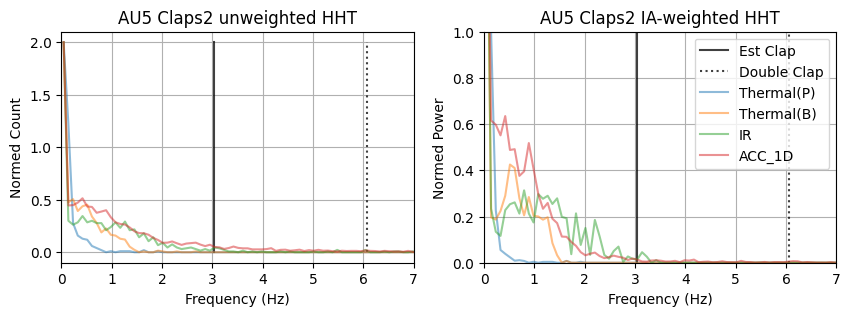

Thermal(P)
Thermal(B)
IR
ACC_1D


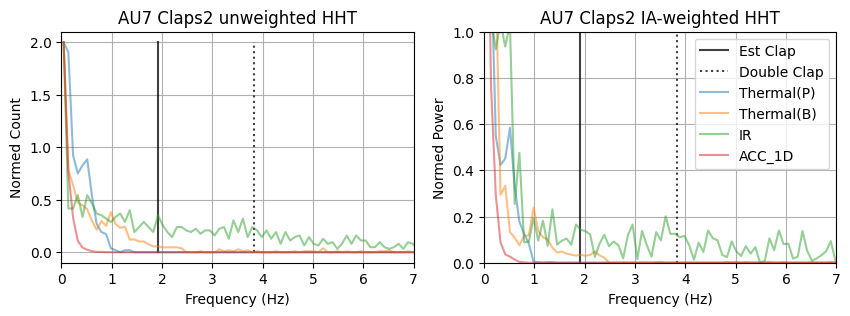

In [133]:
samplerates['ACC_1D'] = 60

for part in ['AU1','AU2','AU3','AU4','AU5','AU7']:
    event = 'Claps2'
    plt.figure(figsize=(10, 3))
    plt.subplots_adjust(hspace=0.4)
    plt.subplot(121)
    plt.xticks(np.arange(12)*1)
    plt.xlim(0, 7)
    plt.plot(claps1_Hz[part]*np.array([1,1]),[0,2],c ='k',alpha = 0.75,label='Est Clap')
    plt.plot(2*claps1_Hz[part]*np.array([1,1]),[0,2],c ='k',alpha = 0.75,linestyle=':',label='Double Clap')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Normed Count')
    plt.title(part+' ' + event +' unweighted HHT')
    plt.grid()
    
    plt.subplot(122) 
    plt.xticks(np.arange(12)*1)
    plt.xlim(0, 7)
    plt.ylim(0, 1)
    plt.plot(claps1_Hz[part]*np.array([1,1]),[0,2],c ='k',alpha = 0.75,label='Est Clap')
    plt.plot(2*claps1_Hz[part]*np.array([1,1]),[0,2],c ='k',alpha = 0.75,linestyle=':',label='Double Clap')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Normed Power')
    plt.title(part+' ' + event +' IA-weighted HHT')
    
    for s in ['Thermal(P)','Thermal(B)','IR', 'ACC_1D',]:
        print(s)
        ClapIMFs = CIMFs[s]
        fs = samplerates[s]
        sig = ClapIMFs.loc[383:405,part]
        timestamps = np.array(sig.index)
        W = sig.to_numpy()
        IP, IF, IA = emd.spectra.frequency_transform(W, fs, 'nht')
        
        freq_edges, freq_centres = emd.spectra.define_hist_bins(0, 12, 128, 'linear')
        f, spec_weighted = emd.spectra.hilberthuang(IF, IA, freq_edges, sum_imfs=False)
        f, spec_unweighted = emd.spectra.hilberthuang(IF, np.ones_like(IA), freq_edges, sum_imfs=False)

        plt.subplot(121)
        mrange = spec_unweighted.transpose().max()/2
        plt.plot(freq_centres, spec_unweighted/mrange,alpha = 0.5,label=s)
        
        plt.subplot(122)
        mrange = spec_weighted.transpose().max()/2
        plt.plot(freq_centres, spec_weighted/mrange,alpha = 0.5,label=s)
    plt.legend()
    plt.grid()
    plt.savefig('./plots/'+ 'HHTwuw'+'_' + event +'_'+part+'.png',dpi = 300)
    plt.show()


# now consider energy in these measurements at clapping frequencies

In [134]:
i = 3
s =source_labels[sources[i]] 
print(s)
f
ClapIMFs = CIMFs[s]
df_ev = ClapIMFs.loc[70:83,:] # 
event = 'Claps1'
timestamps = np.array(df_ev.index)
W = df_ev.to_numpy()

IP, IF, IA = emd.spectra.frequency_transform(W, fs, 'nht')


Thermal(B)


In [ ]:
def get_spectrogram(datain,F,W,J,scale='log'):
    '''Makes a spectrogram of the given data.
    #
    df: dataframe with data
    F: sampling frequency
    W: Window size
    J: Separation between windows
    #
    output: if input is Series output is a signle DF with spectrogram
            if intput is DF the output is dictionary with one spectrogram per column of the input dataframe
    '''
    K = range(0,len(datain)-W,J) # starting point for the windows
    K0 = [int(x+W/2) for x in K] # placing them in the middle point timestamp
    new_index = [datain.index[x] for x in K0] # extracting those timestamps
    col_freqs = [x*F/W for x in range(int(W/2)+1) ] # values of resolved freqs
    #   print(len(new_index),len(col_freqs))
    han = np.hanning(W)
    #dic = {'window_size':W,'sampling_frequency':F}
    #
    dic = {}
    for col in datain.columns:
        fourier = np.zeros((len(new_index),len(col_freqs)))
        temp = np.zeros((1,int(W/2)+1))
        j = 0
        D = datain[col]
#         D = D.diff() # discrete derivative
        D = D.dropna() # discarding nans and concatenating
        if len(D)==0:
            continue
        #   
        K0 = range(0,len(D)-W,J) # starting point for the windows
        for T0 in K0:
            data0 = D.iloc[T0:T0+W]*han
            if scale=='log':
                temp = 10*np.log10(2*abs(np.fft.fft(data0,axis=0)))
            elif scale=='abs':
                temp = abs(np.fft.fft(data0,axis=0))
            fourier[j,:] = temp[:int(W/2)+1]
            j = 1 + j
            #
        res = pd.DataFrame(fourier,index=new_index,columns=col_freqs)
#         res1 = res / (res.columns) # multiplicative adjustment for discrete derivative
        dic[col] = res#1      
        #print('Ready with ',col)
    output = dic
    #
    return output
#
def get_meanpowerspectrum(datain,F,W,J,scale='log'):
    # Obtained average spectrogram using the previous function
    spectrogram = get_spectrogram(datain,F,W,J,scale)
    dic = {}
    for key in spectrogram:
        dic[key] = spectrogram[key].mean(axis=0)
    output = pd.DataFrame(dic,index=dic[key].index)
    return output
#
#